# Movie Recommender System: TF-IDF + K-Means + KNN

## 1. Problem Statement

A user picks a movie they like and the system must return the **10 most similar movies**.

We only have text metadata (overview, genres, tagline) and no user ratings or labels, so this is an **unsupervised** problem. The pipeline is:

```
Movie text  ->  TF-IDF features  ->  K-Means (group similar movies)  ->  KNN (find nearest movies)  ->  Top 10
```

| Component | Role |
|---|---|
| **TF-IDF** | Converts movie text into numeric feature vectors |
| **K-Means** | Trained model that clusters movies into groups of similar content |
| **Silhouette Score** | Evaluation metric used to choose the number of clusters K |
| **K-Nearest Neighbors** | Trained model that retrieves the nearest movies (cosine distance) |
| **Cosine similarity** | The original baseline we compare against |

Recommendation flow:
`user selects movie -> find its K-Means cluster -> keep candidates from that cluster -> rank by KNN (cosine distance) -> top 10`

In [1]:
import os
import ast
import re
import time
import pickle
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# ---- Experiment settings (change here, not inside the code below) ----
RANDOM_STATE = 42
K_VALUES = [10, 20, 30, 40, 50]      # candidate numbers of clusters
SILHOUETTE_SAMPLE_SIZE = 10000       # silhouette is O(n^2), so it is computed on a fixed random sample
N_RECS = 10                          # recommendations returned per movie
CANDIDATE_POOL = 1000                # nearest neighbours fetched before filtering by cluster

## 2. Dataset Loading

Dataset: *The Movies Dataset* (`movies_metadata.csv`, ~45k movies from TMDB).

In [2]:
df = pd.read_csv("movies_metadata.csv", low_memory=False)
print("Raw shape:", df.shape)
df.head()

Raw shape: (45466, 24)


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

## 3. Data Cleaning

Steps: remove duplicates, keep only the columns we need, drop rows without a title, fill missing text with empty strings, parse the `genres` JSON-like string into a list, and extract the release year.

In [4]:
df = df.drop_duplicates().reset_index(drop=True)

# release_date is kept only for the EDA (release year distribution)
df = df[["title", "overview", "genres", "tagline", "vote_average", "popularity", "release_date"]]
print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
title               6
overview          954
genres              0
tagline         25042
vote_average        6
popularity          5
release_date       87
dtype: int64


In [5]:
df = df.dropna(subset=["title"])
df["overview"] = df["overview"].fillna("")
df["tagline"] = df["tagline"].fillna("")


def parse_genres(value):
    """'[{'id': 16, 'name': 'Animation'}, ...]'  ->  ['Animation', ...]"""
    try:
        return [g["name"] for g in ast.literal_eval(value)]
    except (ValueError, SyntaxError, TypeError):
        return []


df["genre_list"] = df["genres"].apply(parse_genres)      # list, used for EDA and evaluation
df["genres"] = df["genre_list"].apply(" ".join)          # string, used as text feature (same as before)

df["release_year"] = pd.to_datetime(df["release_date"], errors="coerce").dt.year
df["vote_average"] = pd.to_numeric(df["vote_average"], errors="coerce")
df["popularity"] = pd.to_numeric(df["popularity"], errors="coerce")
df = df.drop(columns=["release_date"]).reset_index(drop=True)

print("Clean shape:", df.shape)
print(df.isnull().sum())
df.head()

Clean shape: (45443, 8)
title            0
overview         0
genres           0
tagline          0
vote_average     0
popularity       0
genre_list       0
release_year    84
dtype: int64


,title,overview,genres,tagline,vote_average,popularity,genre_list,release_year
0,Toy Story,"Led by Woody, Andy's toys live happily in his ...",Animation Comedy Family,,7.7,21.946943,"[Animation, Comedy, Family]",1995.0
1,Jumanji,When siblings Judy and Peter discover an encha...,Adventure Fantasy Family,Roll the dice and unleash the excitement!,6.9,17.015539,"[Adventure, Fantasy, Family]",1995.0
2,Grumpier Old Men,A family wedding reignites the ancient feud be...,Romance Comedy,Still Yelling. Still Fighting. Still Ready for...,6.5,11.712900,"[Romance, Comedy]",1995.0
3,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",Comedy Drama Romance,Friends are the people who let you be yourself...,6.1,3.859495,"[Comedy, Drama, Romance]",1995.0
4,Father of the Bride Part II,Just when George Banks has recovered from his ...,Comedy,Just When His World Is Back To Normal... He's ...,5.7,8.387519,[Comedy],1995.0


## 4. Exploratory Data Analysis (EDA)

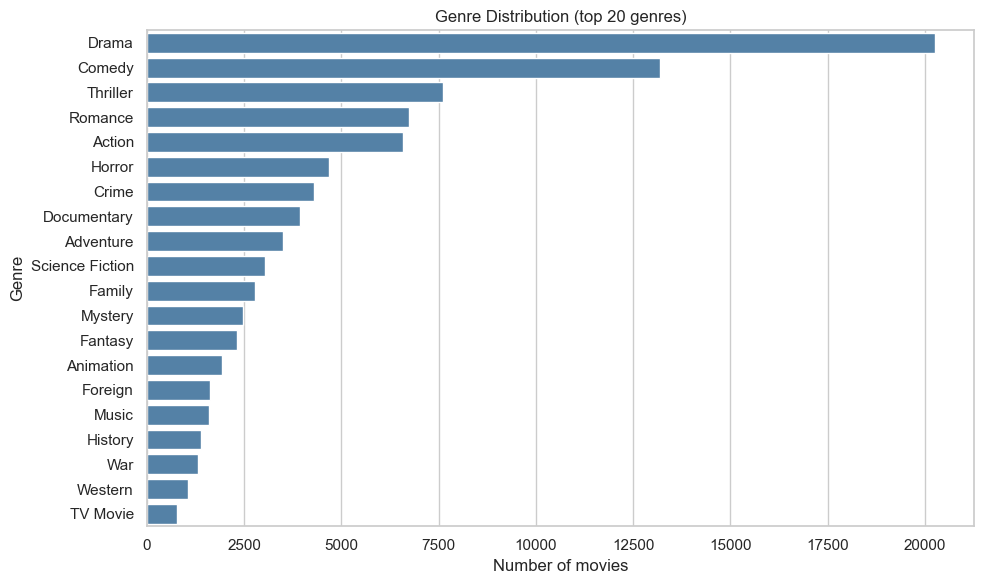

Distinct genres: 20
Movies with no genre: 2442


In [6]:
# Genre distribution
genre_counts = df["genre_list"].explode().value_counts()
top_genres = genre_counts.head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, color="steelblue")
plt.title("Genre Distribution (top 20 genres)")
plt.xlabel("Number of movies")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

print("Distinct genres:", genre_counts.shape[0])
print("Movies with no genre:", int((df["genre_list"].str.len() == 0).sum()))

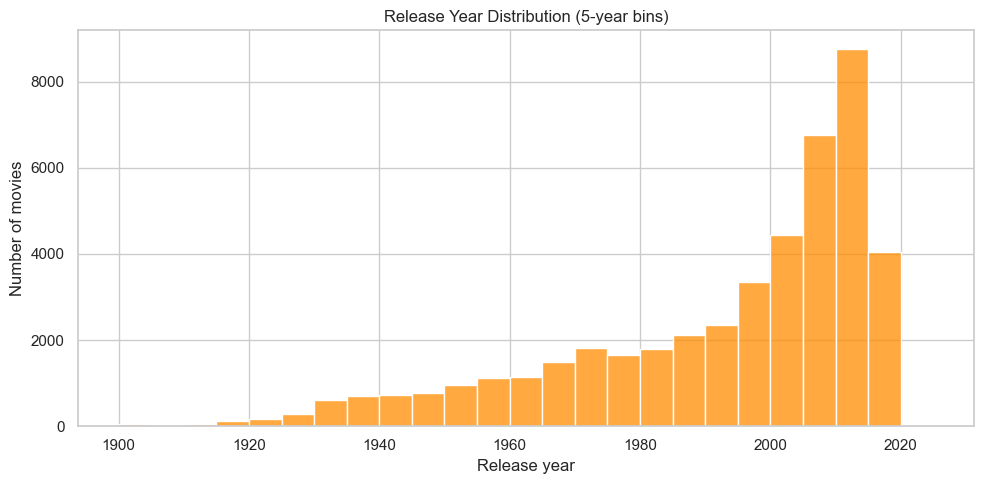

In [7]:
# Release year distribution
years = df["release_year"].dropna()
years = years[(years >= 1900) & (years <= 2025)]

plt.figure(figsize=(10, 5))
sns.histplot(years, bins=range(1900, 2030, 5), color="darkorange")
plt.title("Release Year Distribution (5-year bins)")
plt.xlabel("Release year")
plt.ylabel("Number of movies")
plt.tight_layout()
plt.show()

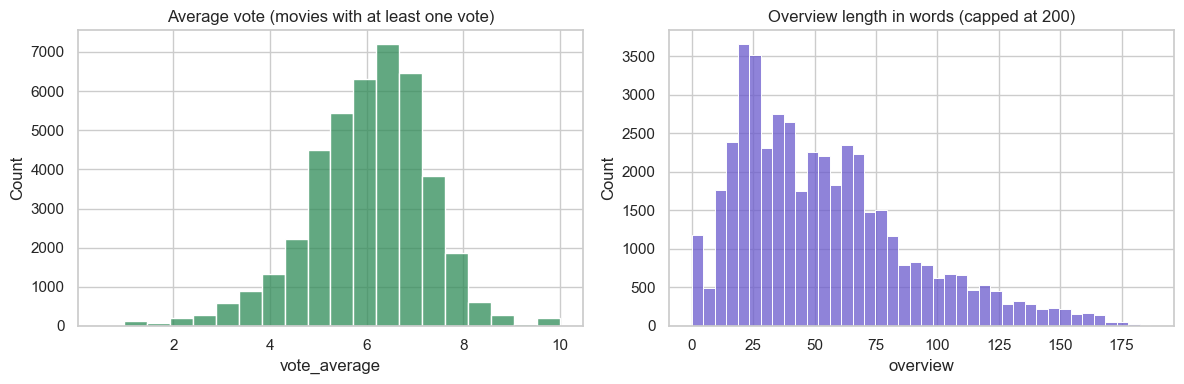

In [8]:
# Extra EDA: rating distribution and amount of text per movie
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

votes = df.loc[df["vote_average"] > 0, "vote_average"]
sns.histplot(votes, bins=20, ax=axes[0], color="seagreen")
axes[0].set_title("Average vote (movies with at least one vote)")

sns.histplot(df["overview"].str.split().str.len().clip(upper=200), bins=40, ax=axes[1], color="slateblue")
axes[1].set_title("Overview length in words (capped at 200)")
plt.tight_layout()
plt.show()

## 5. Feature Engineering

Each movie is represented by one text field, `tags` = overview + genres + tagline. The text is lower-cased, stripped of punctuation and stop-words, and lemmatized.

In [9]:
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def preprocess_text(text):
    text = str(text).lower()                       # lowercase
    text = re.sub(r"[^a-zA-Z\s]", "", text)        # remove punctuation / digits
    words = text.split()
    words = [w for w in words if w not in stop_words]   # remove stop-words
    words = [lemmatizer.lemmatize(w) for w in words]    # lemmatize
    return " ".join(words)


df["tags"] = df["overview"] + " " + df["genres"] + " " + df["tagline"]
df["tags"] = df["tags"].apply(preprocess_text)
df = df.reset_index(drop=True)

# title -> row number (same structure as before, so main.py keeps working)
indices = pd.Series(df.index, index=df["title"]).drop_duplicates()
df[["title", "tags"]].head()

,title,tags
0,Toy Story,led woody andys toy live happily room andys bi...
1,Jumanji,sibling judy peter discover enchanted board ga...
2,Grumpier Old Men,family wedding reignites ancient feud nextdoor...
3,Waiting to Exhale,cheated mistreated stepped woman holding breat...
4,Father of the Bride Part II,george bank recovered daughter wedding receive...


## 6. TF-IDF (feature extraction)

Unchanged from the original project: unigrams + bigrams, max 50,000 features.

In [10]:
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), stop_words="english")
tfidf_matrix = tfidf.fit_transform(df["tags"])

X = tfidf_matrix
N_DOCS = X.shape[0]
density = X.nnz / (X.shape[0] * X.shape[1])
print("TF-IDF matrix shape:", X.shape)
print(f"Non-zero entries: {X.nnz:,} (density {density:.4%})")

TF-IDF matrix shape: (45443, 50000)
Non-zero entries: 1,548,209 (density 0.0681%)


## 7. Existing Cosine Similarity Baseline

The original recommender: compute cosine similarity between the selected movie and **every** movie, then sort. There is no trained model here, only a similarity computation, so we keep it as a baseline to compare against.

In [11]:
def title_to_idx(title):
    idx = indices[title]
    return int(idx.iloc[-1]) if isinstance(idx, pd.Series) else int(idx)   # duplicate titles: last one wins (same as main.py)


def cosine_rec(i, n=N_RECS):
    """Baseline: top-n by cosine similarity over the whole dataset (row index in, row indices out)."""
    sims = cosine_similarity(X[i], X).ravel()
    sims[i] = -1.0                                  # never recommend the movie itself
    top = np.argsort(-sims)[:n]
    return top, sims[top]


def recommend_cosine(title, n=N_RECS):
    if title not in indices:
        return "Movie not found"
    top, sims = cosine_rec(title_to_idx(title), n)
    return pd.DataFrame({"title": df["title"].iloc[top].values, "similarity": sims.round(4)})


recommend_cosine("Avatar", 5)

,title,similarity
0,Avatar 2,0.2559
1,The Inhabited Island,0.1861
2,Thor: Ragnarok,0.1854
3,Moontrap: Target Earth,0.1747
4,A Trip to the Moon,0.1671


## 8. K-Means Training

K-Means groups the TF-IDF vectors into K clusters of similar movies. The right K is unknown, so we train one model for each candidate K (10, 20, 30, 40, 50) and compare them in the next two sections.

TF-IDF rows are L2-normalised, so Euclidean K-Means on them behaves like cosine-based (spherical) clustering. `n_init=3` is used during the search to keep it fast; the final model uses `n_init=10`.

In [12]:
kmeans_runs = {}

for k in K_VALUES:
    t0 = time.time()
    km = KMeans(n_clusters=k, n_init=3, random_state=RANDOM_STATE)
    km.fit(X)
    kmeans_runs[k] = {"labels": km.labels_, "inertia": km.inertia_}
    print(f"K={k:>2}  inertia={km.inertia_:,.1f}  fit time={time.time() - t0:.1f}s")

K=10  inertia=44,083.8  fit time=13.7s
K=20  inertia=43,752.0  fit time=20.1s
K=30  inertia=43,546.1  fit time=34.6s
K=40  inertia=43,410.1  fit time=42.2s
K=50  inertia=43,348.0  fit time=48.9s


## 9. Silhouette Score Evaluation

The Silhouette Score measures how well each movie fits its own cluster compared with the nearest other cluster. It ranges from -1 to 1, and higher is better. We use **cosine distance** (the same notion of similarity used for recommendation).

Silhouette needs all pairwise distances, so it is computed on one fixed random sample of movies, the same sample for every K, which keeps the comparison fair.

In [13]:
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(N_DOCS, size=min(SILHOUETTE_SAMPLE_SIZE, N_DOCS), replace=False)
X_sample = X[sample_idx]

rows = []
for k in K_VALUES:
    labels_sample = kmeans_runs[k]["labels"][sample_idx]
    score = silhouette_score(X_sample, labels_sample, metric="cosine")
    rows.append({"K": k, "silhouette": score, "inertia": kmeans_runs[k]["inertia"]})
    print(f"K={k:>2}  silhouette (cosine) = {score:.4f}")

sil_df = pd.DataFrame(rows)
sil_df

K=10  silhouette (cosine) = -0.0032
K=20  silhouette (cosine) = -0.0079
K=30  silhouette (cosine) = -0.0078
K=40  silhouette (cosine) = -0.0040
K=50  silhouette (cosine) = -0.0122


,K,silhouette,inertia
0,10,-0.003214,44083.829935
1,20,-0.007901,43752.009494
2,30,-0.007781,43546.137520
3,40,-0.003997,43410.103667
4,50,-0.012177,43348.043110


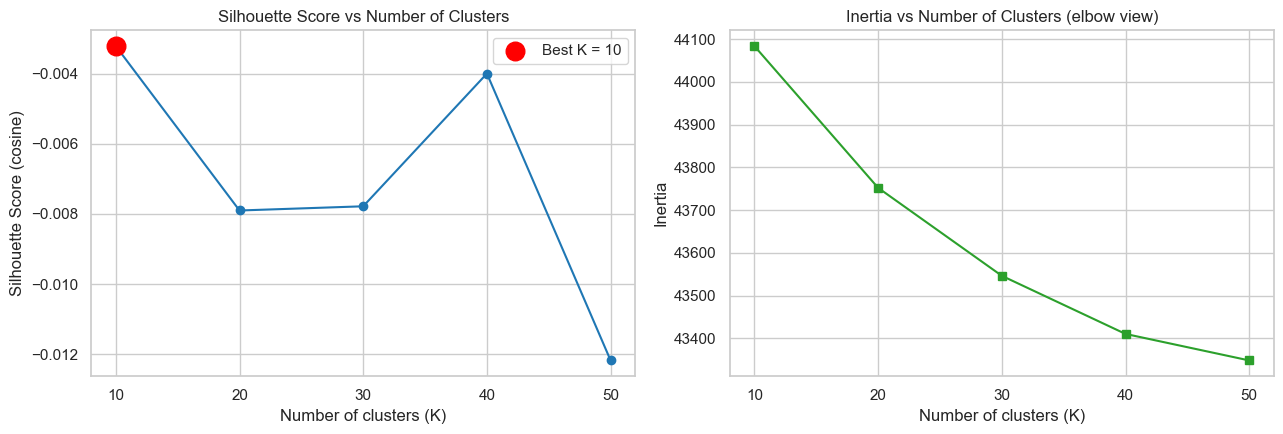

In [14]:
best_row = sil_df.loc[sil_df["silhouette"].idxmax()]
best_k = int(best_row["K"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(sil_df["K"], sil_df["silhouette"], marker="o", color="tab:blue")
axes[0].scatter([best_k], [best_row["silhouette"]], s=180, color="red", zorder=5, label=f"Best K = {best_k}")
axes[0].set_title("Silhouette Score vs Number of Clusters")
axes[0].set_xlabel("Number of clusters (K)")
axes[0].set_ylabel("Silhouette Score (cosine)")
axes[0].set_xticks(K_VALUES)
axes[0].legend()

axes[1].plot(sil_df["K"], sil_df["inertia"], marker="s", color="tab:green")
axes[1].set_title("Inertia vs Number of Clusters (elbow view)")
axes[1].set_xlabel("Number of clusters (K)")
axes[1].set_ylabel("Inertia")
axes[1].set_xticks(K_VALUES)

plt.tight_layout()
plt.show()

**Reading the result:** silhouette values for sparse, high-dimensional text (50,000 TF-IDF features) are normally low, often close to 0, because text vectors are far apart in almost every direction. What matters is the *relative* comparison between K values; the K with the highest score is selected. Inertia always falls as K grows, so it cannot be used alone to choose K.

## 10. Optimal K Selection and Final K-Means Model

The K with the highest Silhouette Score is selected and the final model is trained with it (more restarts, `n_init=10`).

In [15]:
print(f"Selected K = {best_k}  (silhouette = {best_row['silhouette']:.4f})")

kmeans_model = KMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE)
kmeans_model.fit(X)

# add the cluster label to every movie
df["cluster"] = kmeans_model.labels_
cluster_labels = df["cluster"].to_numpy()

final_silhouette = silhouette_score(X_sample, cluster_labels[sample_idx], metric="cosine")
print(f"Final model silhouette (same sample): {final_silhouette:.4f}")
print(f"Final model inertia: {kmeans_model.inertia_:,.1f}")
df[["title", "genres", "cluster"]].head(10)

Selected K = 10  (silhouette = -0.0032)
Final model silhouette (same sample): -0.0035
Final model inertia: 44,054.2


,title,genres,cluster
0,Toy Story,Animation Comedy Family,0
1,Jumanji,Adventure Fantasy Family,0
2,Grumpier Old Men,Romance Comedy,1
3,Waiting to Exhale,Comedy Drama Romance,1
4,Father of the Bride Part II,Comedy,3
5,Heat,Action Crime Drama Thriller,5
6,Sabrina,Comedy Romance,1
7,Tom and Huck,Action Adventure Drama Family,0
8,Sudden Death,Action Adventure Thriller,5
9,GoldenEye,Adventure Action Thriller,5


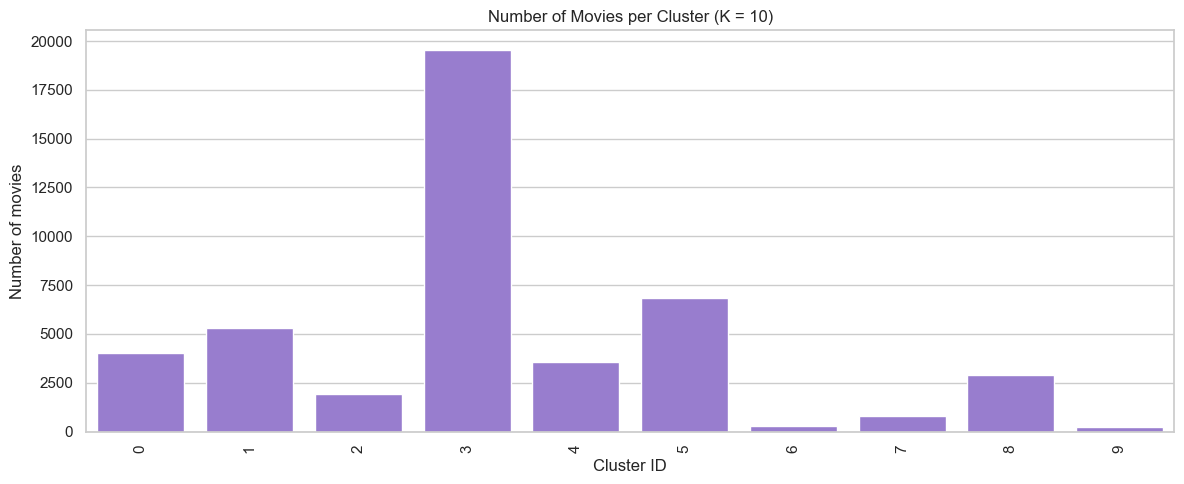

Smallest cluster: 226 | largest cluster: 19564 | mean: 4544.3


In [16]:
# Number of movies per cluster
cluster_sizes = df["cluster"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
sns.barplot(x=cluster_sizes.index, y=cluster_sizes.values, color="mediumpurple")
plt.title(f"Number of Movies per Cluster (K = {best_k})")
plt.xlabel("Cluster ID")
plt.ylabel("Number of movies")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("Smallest cluster:", cluster_sizes.min(), "| largest cluster:", cluster_sizes.max(), "| mean:", round(cluster_sizes.mean(), 1))

In [17]:
# What does each cluster represent? Show the highest-weighted TF-IDF terms of every cluster centre.
terms = np.array(tfidf.get_feature_names_out())
top_term_idx = kmeans_model.cluster_centers_.argsort(axis=1)[:, ::-1][:, :8]

for c in range(best_k):
    print(f"Cluster {c:>2} ({cluster_sizes[c]:>5} movies): {', '.join(terms[top_term_idx[c]])}")

Cluster  0 ( 4041 movies): family, animation, adventure, comedy, drama, comedy family, drama family, life
Cluster  1 ( 5302 movies): romance, love, drama romance, drama, comedy, comedy romance, fall, woman
Cluster  2 ( 1920 movies): war, world war, drama, history, drama war, world, ii, war ii
Cluster  3 (19564 movies): comedy, drama, life, film, young, man, story, horror
Cluster  4 ( 3545 movies): documentary, film, music, life, world, story, interview, history
Cluster  5 ( 6826 movies): thriller, crime, mystery, action, drama, crime drama, drama thriller, horror
Cluster  6 (  298 movies): comedy, comedy drama, drama comedy, drama, zostaje, zorro, zorba, zoom
Cluster  7 (  825 movies): movie, tv movie, tv, movie drama, drama, family, drama tv, comedy
Cluster  8 ( 2896 movies): science, science fiction, fiction, horror science, action, horror, earth, fiction thriller
Cluster  9 (  226 movies): drama, overview, overview comedy, overview drama, comedy, overview documentary, overview actio

## 11. KNN Training

`NearestNeighbors` with cosine distance and brute-force search. Fitting it stores the TF-IDF matrix and prepares it for neighbour queries; `kneighbors()` then returns the nearest movies to a query vector. (Cosine distance = 1 - cosine similarity.)

In [18]:
knn_model = NearestNeighbors(metric="cosine", algorithm="brute")
knn_model.fit(X)
print(knn_model)

NearestNeighbors(algorithm='brute', metric='cosine')


## 12. Recommendation Generation (K-Means + KNN)

1. Find the selected movie's K-Means cluster.
2. Ask KNN for the nearest `CANDIDATE_POOL` movies.
3. Keep only the neighbours that are in the **same cluster**, ordered by cosine distance.
4. Return the top 10. If a cluster has fewer than 10 close members, the list is topped up with the next nearest movies from other clusters, so the user always receives 10 results.

In [19]:
def knn_rec(i, n=N_RECS):
    """KNN over the whole dataset (no clustering)."""
    dist, ind = knn_model.kneighbors(X[i], n_neighbors=n + 1)
    ind, dist = ind[0], dist[0]
    keep = ind != i
    return ind[keep][:n], 1.0 - dist[keep][:n]


def hybrid_rec(i, n=N_RECS, pool=CANDIDATE_POOL):
    """K-Means cluster filter + KNN ranking."""
    pool = min(pool, N_DOCS - 1)
    dist, ind = knn_model.kneighbors(X[i], n_neighbors=pool + 1)
    ind, dist = ind[0], dist[0]
    keep = ind != i
    ind, dist = ind[keep], dist[keep]

    same_cluster = cluster_labels[ind] == cluster_labels[i]
    chosen = list(np.flatnonzero(same_cluster)[:n])
    if len(chosen) < n:                                    # small cluster: top up from nearest others
        others = np.flatnonzero(~same_cluster)
        chosen += list(others[: n - len(chosen)])
    chosen = np.array(chosen, dtype=int)
    return ind[chosen], 1.0 - dist[chosen]


def recommend_cluster_knn(title, n=N_RECS):
    if title not in indices:
        return "Movie not found"
    i = title_to_idx(title)
    rec_idx, sims = hybrid_rec(i, n)
    out = pd.DataFrame({
        "title": df["title"].iloc[rec_idx].values,
        "cluster": cluster_labels[rec_idx],
        "similarity": sims.round(4),
    })
    print(f"'{title}' belongs to cluster {cluster_labels[i]}")
    return out


recommend_cluster_knn("Avatar")

'Avatar' belongs to cluster 8


,title,cluster,similarity
0,Avatar 2,8,0.2559
1,The Inhabited Island,8,0.1861
2,Thor: Ragnarok,8,0.1854
3,Moontrap: Target Earth,8,0.1747
4,A Trip to the Moon,8,0.1671
5,Désiré,8,0.1634
6,Nightmare City 2035,8,0.1634
7,France société anonyme,8,0.1634
8,Frank Herbert's Dune,8,0.1625
9,The Matrix,8,0.1589


## 13. Model Comparison

We compare three recommenders on the same 300 randomly chosen movies:

* **Cosine similarity (baseline)**: no trained model, searches all movies.
* **KNN (global)**: trained `NearestNeighbors`, searches all movies.
* **K-Means + KNN (final)**: restricts candidates to the movie's cluster, then ranks with KNN.

There are no user ratings, so there is no ground-truth "correct" recommendation. We therefore report proxy metrics:

* *Mean cosine similarity*: how close the recommendations are to the query in TF-IDF space.
* *Mean genre Jaccard*: overlap between the query's genres and each recommendation's genres (1.0 = identical genre sets). Genres are also part of the text features, so this is a sanity check and not independent ground truth.
* *Same-cluster %*: share of recommendations that are in the query's cluster.
* *Time per query*.

Cosine and global KNN use the same metric, so they should return the same movies; that agreement is a useful correctness check. The hybrid can never have a higher raw similarity than global KNN, because it searches a subset. What it adds is cluster-consistent, topic-coherent results and a trained clustering model.

In [20]:
def genre_jaccard(i, j):
    a, b = set(df["genre_list"].iat[i]), set(df["genre_list"].iat[j])
    union = a | b
    return len(a & b) / len(union) if union else 0.0


methods = {
    "Cosine similarity (baseline)": cosine_rec,
    "KNN (global)": knn_rec,
    "K-Means + KNN (final)": hybrid_rec,
}

has_genre = np.flatnonzero(df["genre_list"].str.len().to_numpy() > 0)
eval_idx = np.random.RandomState(RANDOM_STATE).choice(has_genre, size=300, replace=False)

results, all_recs = [], {}
for name, fn in methods.items():
    sims_all, jac_all, same_all, recs = [], [], [], []
    t0 = time.perf_counter()
    for i in eval_idx:
        rec_idx, sims = fn(i)
        recs.append(set(rec_idx))
        sims_all.append(np.mean(sims))
        jac_all.append(np.mean([genre_jaccard(i, j) for j in rec_idx]))
        same_all.append(np.mean(cluster_labels[rec_idx] == cluster_labels[i]))
    elapsed = (time.perf_counter() - t0) / len(eval_idx) * 1000
    all_recs[name] = recs
    results.append({
        "Method": name,
        "Mean cosine similarity": round(float(np.mean(sims_all)), 4),
        "Mean genre Jaccard": round(float(np.mean(jac_all)), 4),
        "Same-cluster %": round(float(np.mean(same_all)) * 100, 1),
        "ms / query": round(elapsed, 1),
    })

comparison_df = pd.DataFrame(results).set_index("Method")
display(comparison_df)

agree = np.mean([len(a & b) / N_RECS for a, b in zip(all_recs["Cosine similarity (baseline)"], all_recs["KNN (global)"])])
print(f"Top-{N_RECS} overlap, cosine baseline vs global KNN: {agree:.1%} (expected ~100%, only ties can differ)")

,Mean cosine similarity,Mean genre Jaccard,Same-cluster %,ms / query
Method,,,,
Cosine similarity (baseline),0.2118,0.4374,54.6,43.3
KNN (global),0.2118,0.4374,54.6,43.4
K-Means + KNN (final),0.1890,0.5273,100.0,43.1


Top-10 overlap, cosine baseline vs global KNN: 94.7% (expected ~100%, only ties can differ)


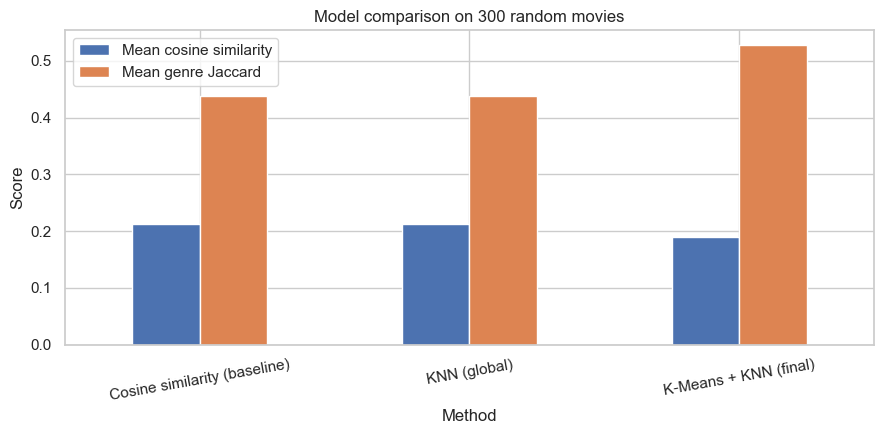

In [21]:
comparison_df[["Mean cosine similarity", "Mean genre Jaccard"]].plot(kind="bar", figsize=(9, 4.5), rot=10)
plt.title("Model comparison on 300 random movies")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

## 14. Save Models

All artefacts that `main.py` loads are written next to the notebook. `df.pkl` is saved **after** the `cluster` column was added.

In [22]:
def save_pickle(obj, path):
    with open(path, "wb") as f:
        pickle.dump(obj, f)


df.to_pickle("df.pkl")
save_pickle(indices, "indices.pkl")
save_pickle(tfidf, "tfidf.pkl")
save_pickle(tfidf_matrix, "tfidf_matrix.pkl")
save_pickle(kmeans_model, "kmeans_model.pkl")
save_pickle(knn_model, "knn_model.pkl")

for name in ["df.pkl", "indices.pkl", "tfidf.pkl", "tfidf_matrix.pkl", "kmeans_model.pkl", "knn_model.pkl"]:
    print(f"{name:<20} {os.path.getsize(name) / 1e6:8.1f} MB")

df.pkl                   31.0 MB
indices.pkl               1.5 MB
tfidf.pkl                 2.0 MB
tfidf_matrix.pkl         18.8 MB
kmeans_model.pkl          4.2 MB
knn_model.pkl            18.8 MB


In [23]:
# Sanity check: reload the saved models and make sure they behave like the in-memory ones
with open("kmeans_model.pkl", "rb") as f:
    km_loaded = pickle.load(f)
with open("knn_model.pkl", "rb") as f:
    knn_loaded = pickle.load(f)

assert (km_loaded.labels_ == df["cluster"].to_numpy()).all(), "cluster labels in df.pkl do not match kmeans_model.pkl"
assert km_loaded.n_clusters == best_k
d1, i1 = knn_loaded.kneighbors(X[0], n_neighbors=5)
d2, i2 = knn_model.kneighbors(X[0], n_neighbors=5)
assert (i1 == i2).all()
print("Saved models reload correctly.")

Saved models reload correctly.


## 15. Example Recommendations

In [24]:
wanted = ["Avatar", "Toy Story", "The Dark Knight", "Titanic", "The Matrix"]
examples = [t for t in wanted if t in indices][:4]
if not examples:                                        # in case none of the titles exist in the data
    examples = df["title"].sample(3, random_state=RANDOM_STATE).tolist()

for t in examples:
    print("=" * 70)
    display(recommend_cluster_knn(t))

'Avatar' belongs to cluster 8


,title,cluster,similarity
0,Avatar 2,8,0.2559
1,The Inhabited Island,8,0.1861
2,Thor: Ragnarok,8,0.1854
3,Moontrap: Target Earth,8,0.1747
4,A Trip to the Moon,8,0.1671
5,Désiré,8,0.1634
6,Nightmare City 2035,8,0.1634
7,France société anonyme,8,0.1634
8,Frank Herbert's Dune,8,0.1625
9,The Matrix,8,0.1589


'Toy Story' belongs to cluster 0


,title,cluster,similarity
0,Toy Story 2,0,0.3952
1,Toy Story 3,0,0.3657
2,Small Fry,0,0.2539
3,Superstar Goofy,0,0.1719
4,Andy Kaufman Plays Carnegie Hall,0,0.1200
5,Tatu and Patu,0,0.1143
6,Bar Sport,0,0.1143
7,Father of Four: Never Gives Up!,0,0.1143
8,Free Birds,0,0.1085
9,"Listen, Darling",0,0.1055


'The Dark Knight' belongs to cluster 5


,title,cluster,similarity
0,Azumi,5,0.1784
1,Sniper 3,5,0.1505
2,The Frontier,5,0.1502
3,Chronicle of a Death Foretold,5,0.1390
4,Game Over,5,0.1390
5,Direct Contact,5,0.1356
6,Ong Bak 2,5,0.1273
7,The General Died at Dawn,5,0.1255
8,Bablo,5,0.1230
9,Pitbull,5,0.1230


'Titanic' belongs to cluster 1


,title,cluster,similarity
0,Fixing Pete,1,0.1975
1,Перекресток,1,0.1975
2,Путь к себе,1,0.1975
3,The Widow Couderc,1,0.1879
4,Madame Bovary,1,0.1712
5,Fly Away,1,0.1712
6,The Woman Who Drinks,1,0.1712
7,Tentação,1,0.1712
8,Blind,1,0.1712
9,Kolmistaan,1,0.1712


## 16. Conclusion

* **TF-IDF** turns each movie's overview, genres and tagline into a numeric vector (feature extraction).
* **K-Means** (trained model) clusters the movies into groups of similar content. K was chosen from {10, 20, 30, 40, 50} by the highest **Silhouette Score**.
* **K-Nearest Neighbors** (trained model, cosine distance, brute force) finds the nearest movies to the selected one.
* The final recommender uses **K-Means to narrow the candidates to the movie's cluster and KNN to rank them**, returning the top 10. The old cosine-similarity approach is kept only as a baseline.
* The trained models are saved as `kmeans_model.pkl` and `knn_model.pkl` and loaded by the FastAPI backend (`main.py`).

**Limitations.** Content-only recommendations ignore user behaviour, so they cannot capture taste. Silhouette scores on sparse text are low in absolute terms. The genre-overlap metric is a proxy, not a measure of true user satisfaction. Possible improvements: word embeddings or sentence-transformers instead of TF-IDF, and adding ratings (collaborative filtering).

**Viva summary:** *TF-IDF is used for feature extraction. K-Means is used to cluster similar movies, and K-Nearest Neighbors is used to find the nearest movies for recommendation. The K-Means model is evaluated using Silhouette Score, and the trained models are saved as .pkl files.*

In [25]:
print(f"Movies: {N_DOCS:,} | TF-IDF features: {X.shape[1]:,}")
print(f"Best K by silhouette: {best_k} (score {best_row['silhouette']:.4f})")
print()
print(comparison_df)

Movies: 45,443 | TF-IDF features: 50,000
Best K by silhouette: 10 (score -0.0032)

                              Mean cosine similarity  Mean genre Jaccard  \
Method                                                                     
Cosine similarity (baseline)                  0.2118              0.4374   
KNN (global)                                  0.2118              0.4374   
K-Means + KNN (final)                         0.1890              0.5273   

                              Same-cluster %  ms / query  
Method                                                    
Cosine similarity (baseline)            54.6        43.3  
KNN (global)                            54.6        43.4  
K-Means + KNN (final)                  100.0        43.1  
